<hr>
<br>
<br>
<br>
<h1><center>AI for Quantitative Trading Strategies      </center></h1>
<h1><center>-      </center></h1>
<h2><center>A Simple Linear Model      </center></h2>
<br>
<br>
<hr>
<br>

<br>
<br>
<h2>Purpose</h2>
<br>
<hr>
A notebook to develop an AI system aiming at trading intraday on cryptocurrencies
<br>
<br>

<br>
<br>
<h2>Imports</h2>
<br>
<hr>
<br>

In [33]:
# Pandas and Python
import pandas as pd
pd.options.display.float_format = '{:.4f}'.format
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
import numpy as np
import os
import time

# Graphic Libraries
import plotly.io as pio
pio.templates.default = "simple_white"
pio.renderers.default = "notebook"
import matplotlib.pyplot as plt
from IPython.display import clear_output

# AI and stats
import statsmodels.api as sm
import xgboost
from xgboost import XGBRegressor
import sklearn



<br>
<br>
<h2>Notebook Parameters</h2>
<br>
<hr>
<br>

In [34]:
# Define data path
data_path = "/Users/veli/Desktop/Misc/Python Scritps /QuantTradingStrategies/in_sample/"

# Risk free rate assumption
risk_free_rate = 0.05 # % per year
rfr_hourly = (1 + risk_free_rate)**(1 / (24*365)) - 1

# Suggested training set
start_date_train = "2023-01-24"
last_date_train = "2024-01-24"

# Suggested validation set
start_date_validate = "2024-01-25"
last_date_validate = "2024-07-24"

# Test set (Unavailable)
# start_date_test = "2024-07-25"
# last_date_test = "2025-01-24"

# Maximum number of features to use
max_nb_features = 20

# Random seed for feature selection
random_seed = 0

# Set a level of transaction costs
tc = 0.0000


<br>
<br>
<h2>Data Loading</h2>
<br>
<hr>
<br>

In [35]:
# Main data
data = pd.read_csv(
    f"{data_path}data_in_sample.csv",
    index_col=0,
    header=[0,1],
)

# Make sure that the index is in the right format
data.index = pd.to_datetime(data.index)

# Visualize data
data


open                                                   \
                     VANRY    EGLD BTS    KEY HIPPO  FRONT    BLZ       ETH   
2023-01-24 00:00:00    NaN 44.2700 NaN    NaN   NaN    NaN 0.0720 1628.1900   
2023-01-24 01:00:00    NaN 43.9800 NaN    NaN   NaN    NaN 0.0721 1626.9000   
2023-01-24 02:00:00    NaN 43.9000 NaN    NaN   NaN    NaN 0.0715 1632.3100   
2023-01-24 03:00:00    NaN 44.3100 NaN    NaN   NaN    NaN 0.0729 1638.6400   
2023-01-24 04:00:00    NaN 44.3100 NaN    NaN   NaN    NaN 0.0725 1635.8000   
...                    ...     ...  ..    ...   ...    ...    ...       ...   
2024-07-24 19:00:00 0.1290 34.6580 NaN 0.0052   NaN 0.8868 0.1757 3416.6600   
2024-07-24 20:00:00 0.1262 34.3410 NaN 0.0052   NaN 0.8774 0.1740 3381.9400   
2024-07-24 21:00:00 0.1255 34.2090 NaN 0.0051   NaN 0.8722 0.1733 3362.2200   
2024-07-24 22:00:00 0.1257 34.4630 NaN 0.0051   NaN 0.8730 0.1733 3374.6900   
2024-07-24 23:00:00 0.1238 33.7750 NaN 0.0051   NaN 0.8570 0.1712 3335.0000   

                                  ...  return                                 \
                    USUAL   MEME  ...     CKB    ATOM AUCTION    ARKM POPCAT   
2023-01-24 00:00:00   NaN    NaN  ...     NaN -0.0041     NaN     NaN    NaN   
2023-01-24 01:00:00   NaN    NaN  ...     NaN  0.0023     NaN     NaN    NaN   
2023-01-24 02:00:00   NaN    NaN  ...     NaN  0.0088     NaN     NaN    NaN   
2023-01-24 03:00:00   NaN    NaN  ...     NaN  0.0051     NaN     NaN    NaN   
2023-01-24 04:00:00   NaN    NaN  ...     NaN  0.0064     NaN     NaN    NaN   
...                   ...    ...  ...     ...     ...     ...     ...    ...   
2024-07-24 19:00:00   NaN 0.0159  ... -0.0175 -0.0100 -0.0077 -0.0142    NaN   
2024-07-24 20:00:00   NaN 0.0157  ...  0.0016 -0.0036 -0.0081 -0.0106    NaN   
2024-07-24 21:00:00   NaN 0.0156  ...  0.0174  0.0021 -0.0056  0.0020    NaN   
2024-07-24 22:00:00   NaN 0.0157  ... -0.0107 -0.0150 -0.0154 -0.0087    NaN   
2024-07-24 23:00:00   NaN 0.0154  ... -0.0125 -0.0055 -0.0162 -0.0143    NaN   

                                                  
                    PNUT SPX     AXS     YFI MDT  
2023-01-24 00:00:00  NaN NaN -0.0132 -0.0018 NaN  
2023-01-24 01:00:00  NaN NaN -0.0254  0.0024 NaN  
2023-01-24 02:00:00  NaN NaN  0.0076  0.0141 NaN  
2023-01-24 03:00:00  NaN NaN  0.0000 -0.0003 NaN  
2023-01-24 04:00:00  NaN NaN  0.0144  0.0061 NaN  
...                  ...  ..     ...     ...  ..  
2024-07-24 19:00:00  NaN NaN -0.0144 -0.0067 NaN  
2024-07-24 20:00:00  NaN NaN -0.0025 -0.0005 NaN  
2024-07-24 21:00:00  NaN NaN  0.0017  0.0031 NaN  
2024-07-24 22:00:00  NaN NaN -0.0141 -0.0106 NaN  
2024-07-24 23:00:00  NaN NaN -0.0069 -0.0067 NaN  

[13152 rows x 4521 columns]

In [36]:
# Check what are the fields available
data.columns.get_level_values(0).drop_duplicates()


Index(['open', 'high', 'low', 'close', 'nb_trades', 'volume_coin',
       'volume_usd', 'open_interest', 'open_interest_value', 'funding_rate',
       'return'],
      dtype='object')

In [37]:
# Load pre-processed features
features = pd.DataFrame(
    np.nan,
    index=data["return"].stack().index,
    columns=[],
)

for dirpath, dirnames, filenames in os.walk(data_path):

    # Only keep standard features for the moment
    filenames = [i for i in filenames if "feature" in i]
   
    # Select a random list of features (always the same)
    np.random.seed(random_seed)
    subset_filenames = np.random.choice(
        a=filenames,
        size=min(max_nb_features, len(filenames)),
        replace=False,
    )    
    for filename in subset_filenames:
          
        print(f"Loading {filename}")
        
        # Load feature
        feature = pd.read_csv(
            f"{data_path}{filename}",
            index_col=0,
            header=[0],
        )  
        
        # Make sure that the index is in the right format
        feature.index = pd.to_datetime(feature.index)
        
        # Store in the feature dict
        features[filename.replace(".csv", "")] = feature.stack().reindex(features.index)
           

Loading feature_576016642244.csv
Loading feature_479883256457.csv
Loading feature_349700183501.csv
Loading feature_004212234751.csv
Loading feature_811799367203.csv
Loading feature_902830881058.csv
Loading feature_447214984470.csv
Loading feature_232377146700.csv
Loading feature_025508110388.csv
Loading feature_329046432311.csv
Loading feature_476736937137.csv
Loading feature_914682300606.csv
Loading feature_303410993934.csv
Loading feature_507845208653.csv
Loading feature_360363963222.csv
Loading feature_889641854357.csv
Loading feature_210616715202.csv
Loading feature_161421521526.csv
Loading feature_435201405839.csv
Loading feature_487989591886.csv


<br>
<br>
<h2>Analytics</h2>
<br>
<hr>
Basic Portfolio analytics to invest in some predictions of the future instruments returns
<br>
<br>


<h4>Naive expected returns definition</h4>
One of the recurring stylized facts about financial markets is that short-term returns tend to revert. Let's leverage on this kowledge to create a first very naive expectation of future returns as the reversion of the past hour.
<br> 

In [38]:
expected_returns = -data['return']

<h4>Analytics definition</h4>
In financial machine learning, the aim of minimizing the prediction loss of a model is directly connected to economic interest: minimizing the loss is equivalent to maximizing a financial gain. Hence, it is quite common to directly assess the goodness of fit in terms of economic indicators, the first of them being the Sharpe Ratio.
<br> 

In [39]:
def expected_returns_to_positions(expected_returns):
    """
    Normalize expected returns to make it an investable portfolio
    
    :param expected_returns: pd.DataFrame containing expectations
                             about future instruments prices variations
    """
    
    # Positions will be proportional to ranked alpha
    positions = expected_returns.rank(axis=1)
    
    # Re-scale the leverage
    positions = positions.div(positions.abs().sum(axis=1), axis=0)
    
    # Make the portfolio dollar neutral
    positions = positions.sub(positions.mean(axis=1), axis=0)
    
    return positions


def get_sharpe(pnl_portfolio, rfr_hourly):
    """
    Compute the sharpe ratio
    
    :param pnl_portfolio: pd.Series of returns of the portfolio considered
    :param rfr_hourly: float, the hourly risk free rate
    """
    
    # Compute excess returns
    excess_returns = pnl_portfolio - rfr_hourly
    
    # Compute sharpe ratio
    sharpe_ratio = (
        excess_returns.mean() / excess_returns.std() * np.sqrt(24 * 365)
    )
    
    # Output
    return round(sharpe_ratio, 2)


def pnl_analytics(positions, 
                  returns, 
                  rfr_hourly,
                  lag,
                  tc=0):
    """
    Compute the p&l analytics of the strategy
    
    :param positions: pd.DataFrame, some positions that have been reached
    :param returns: pd.DataFrame containing returns of instruments
    :param rfr_hourly: float, the hourly risk free rate
    :param lag: int, the number of hours to reach the positions
    :param tc: float, the transaction costs
    
    """

    # Compute gross p&l
    pnl = positions.shift(1+lag).mul(returns).sum(axis=1)
    
    # Compute transaction costs
    trades = positions.fillna(0).diff()
    costs = trades.abs().sum(axis=1) * tc
    
    # Net p&l: deduce costs from gross p&l
    pnl = pnl.sub(costs, fill_value=0)
    
    # Compute sharpe
    sharpe = get_sharpe(pnl, rfr_hourly)
    
    return {"sharpe": sharpe,
           "pnl": pnl}


def analyze_expected_returns(
    expected_returns,
    returns,
    rfr_hourly,
    title = "a Nice Try",
    lags = [0,1,2,3,6,12],
    tc = 0,
    plot_option="matplotlib",
):
    """
    Provide an economic analysis of some expected_returns
    
    :param expected_returns: pd.DataFrame containing expectations
                             about future instruments prices variations
    :param returns: pd.DataFrame containing returns of instruments
    :param rfr_hourly: float, the hourly risk free rate
    :param lags: list of int, corresponding to the number of hours to 
                 reach the positions
    :param tc: float, the transaction costs
    :param plot_option: str, the library used to display the cumulative 
                        p&l plot, can be "plotly" or "matplotlib"
    """
    
    # Take positions as a function of expected returns
    positions = expected_returns_to_positions(expected_returns)
    
    # Compute p&l and sharpe for different lags
    pnl_lags = {}
    for lag in lags:
        analytics_lag = pnl_analytics(
            positions=positions, 
            returns=returns, 
            rfr_hourly=rfr_hourly,
            lag=lag,
            tc=tc)
        lag_label = f"Lag {lag}, sharpe={analytics_lag['sharpe']}"
        pnl_lags[lag_label] = analytics_lag["pnl"]
        
    # Compute cumulative returns
    pnl_lags = pd.concat(pnl_lags, axis=1).dropna()
    cumulative_pnl_lags = (1+pnl_lags).cumprod().resample("24h").last()

    # Display
    if plot_option == "plotly":
        
        pd.options.plotting.backend = "plotly"
        
        fig = cumulative_pnl_lags.plot(
            title=f"Cumulative returns of {title}",
        )
        fig.update_layout(yaxis_type="log")
        fig.show()
        
    elif plot_option == "matplotlib":
        
        pd.options.plotting.backend = "matplotlib"

        ax = cumulative_pnl_lags.plot(
            title=f"Cumulative returns of {title}",
            logy=True,
            grid=False,
            figsize=(10, 4),
        )
        plt.show()

    else:
        raise ValueError("plot_option must be either 'plotly' or 'matplotlib'")
    


Testing analytics on our naive expected returns
<br> 

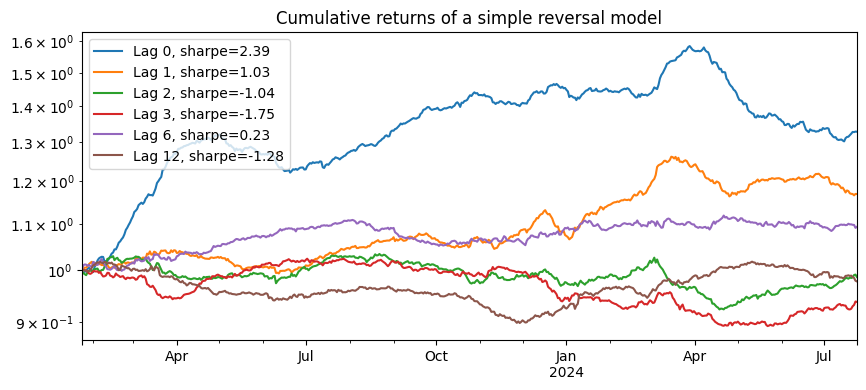

In [40]:
# Analyze it
analyze_expected_returns(
    expected_returns=expected_returns,
    returns=data["return"],
    rfr_hourly=rfr_hourly,
    title="a simple reversal model",
    lags=[0,1,2,3,6,12],
    tc=tc)

<br>
<br>
<h2>A First Model: OLS Predictions</h2>
<br>
<hr>
A multivariate linear model maybe one of the simplest ways to produce a model, hence that is a good starting point, and a good benchmark.
<br>
<br>


<h4>Label definition</h4>
What do we want to predict?
<br> 

In [41]:
label = data["return"].loc[start_date_train:last_date_train
    ].shift(-1).stack()

<h4>Features Pre-processing</h4>
How to process the features ?
<br> 

In [42]:
features_normalized = pd.DataFrame().reindex_like(features)

for feature_name in features.keys():

    print(f"Pre-processing {feature_name}")
    
    # Extract the feature
    feature_normalized = features[feature_name].unstack()

    # Rank the feature to remove outliers
    feature_normalized = feature_normalized.rank(axis=1, pct=True) - 0.5

    # Stack the feature
    feature_normalized = feature_normalized.stack().reindex(
        features_normalized.index
    )

    # Store this normalized version
    features_normalized[feature_name] = feature_normalized

# Replace NaNs by average values, as OLS cannot handle NaNs effectively
features_normalized = features_normalized.fillna(0)

# Only keep datetimes that are common between the label and the features
# for training
common_index = label.index.intersection(features_normalized.index)
features_normalized_train = features_normalized.reindex(common_index)
label = label.reindex(common_index)
                                                        

Pre-processing feature_576016642244
Pre-processing feature_479883256457
Pre-processing feature_349700183501
Pre-processing feature_004212234751
Pre-processing feature_811799367203
Pre-processing feature_902830881058
Pre-processing feature_447214984470
Pre-processing feature_232377146700
Pre-processing feature_025508110388
Pre-processing feature_329046432311
Pre-processing feature_476736937137
Pre-processing feature_914682300606
Pre-processing feature_303410993934
Pre-processing feature_507845208653
Pre-processing feature_360363963222
Pre-processing feature_889641854357
Pre-processing feature_210616715202
Pre-processing feature_161421521526
Pre-processing feature_435201405839
Pre-processing feature_487989591886


<h4>Model Creation</h4>
<br> 

In [43]:
# Create model
model = sm.OLS(
    endog = label,
    exog = sm.add_constant(features_normalized_train),
)

# Fit the model
model = model.fit()


<h4>Model Predictions</h4>
<br> 
<h5>Train Set</h5>
<br> 

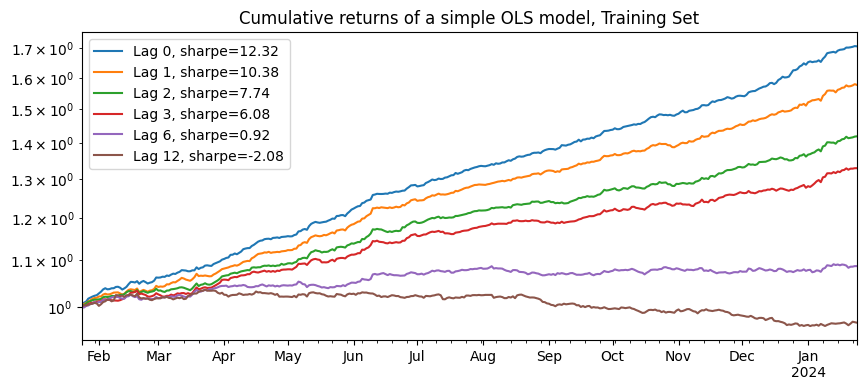

In [44]:
# Make predictions
predictions = model.predict(
    sm.add_constant(features_normalized_train)).unstack()

# Analyse our predictions
analyze_expected_returns(
    expected_returns=predictions,
    returns=data["return"].loc[start_date_train:last_date_train],
    rfr_hourly=rfr_hourly,
    title = "a simple OLS model, Training Set",
    lags = [0,1,2,3,6,12],
    tc = tc)

<br> 
<h5>Validation Set</h5>
<br> 

In [45]:
# Extract features on the validation set
features_normalized_validate = features_normalized.sort_index().loc[
    start_date_validate:last_date_validate]

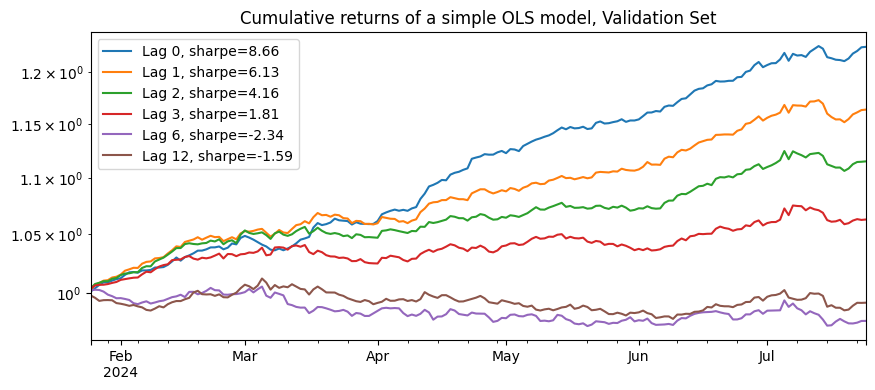

In [46]:
# Make predictions
predictions = model.predict(
    sm.add_constant(features_normalized_validate)).unstack()

# Analyse our predictions
analyze_expected_returns(
    expected_returns=predictions,
    returns=data["return"].loc[start_date_validate:last_date_validate],
    rfr_hourly=rfr_hourly,
    title = "a simple OLS model, Validation Set",
    lags = [0,1,2,3,6,12],
    tc = tc)